# 11 · All results, plotted

Every file in `results/` turned into a figure, with a note on how to read each one. Figures are written to `results/figures/` as PNGs.

| Source file | Figures |
|---|---|
| `summary_multimodal.csv` | 1 — performance by model |
| `fold_metrics_multimodal.csv` | 2 — spread across outer folds; 3 — metric grid |
| `comparisons_multimodal.csv` + the primary result | 4 — forest plot of paired differences |
| `permutation_tests/structural_block_multimodal/` | 5 — the primary null |
| `permutation_tests/labels_multimodal/` | 6 — beats-chance nulls for all seven models |
| `selections_multimodal.csv` | 7 — learned MKL weights, C and thresholds |
| `predictions_multimodal.csv` | 8 — ROC and PR curves; 9 — score distributions |
| `stability_multimodal.csv` | 10 — per-participant prediction stability |
| `primal_weights_multimodal.npz` | 11 — structural weight profile; 12 — functional network weights |
| `*_niak_functional.csv` | 13 — functional-only run versus the multimodal run |

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

MODELS = ["structural", "functional", "early_fusion", "equal_weight", "mkl", "stacking", "confounds_only"]
COLORS = dict(zip(MODELS, plt.cm.tab10.colors))


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def save(fig, name):
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")
    print("saved", name)


def load_null(folder):
    chunks = sorted((RESULTS / "permutation_tests" / folder).glob("chunk_*.csv"))
    return pd.concat([pd.read_csv(c) for c in chunks], ignore_index=True)

In [2]:
summary = pd.read_csv(RESULTS / "metrics" / "summary_multimodal.csv")
folds = pd.read_csv(RESULTS / "metrics" / "fold_metrics_multimodal.csv")
comparisons = pd.read_csv(RESULTS / "metrics" / "comparisons_multimodal.csv")
beats = pd.read_csv(RESULTS / "metrics" / "beats_chance_multimodal.csv")
selections = pd.read_csv(RESULTS / "metrics" / "selections_multimodal.csv")
predictions = pd.read_csv(RESULTS / "predictions" / "predictions_multimodal.csv")
stability = pd.read_csv(RESULTS / "metrics" / "stability_multimodal.csv")
primary = json.loads((RESULTS / "metrics" / "primary_result_multimodal.json").read_text())
block_null = load_null("structural_block_multimodal")
label_null = load_null("labels_multimodal")
order = summary.sort_values("auc_mean")["model"].tolist()
print(f"{len(folds)} fold-level rows | {len(predictions)} predictions | "
      f"{len(block_null)} block permutations | {len(label_null)} label permutations")
print(f"primary verdict: {primary['result']} (ΔAUC {primary['mean_delta_auc']:+.4f}, p = {primary['p_block_permutation']:.3f})")

350 fold-level rows | 5740 predictions | 1000 block permutations | 1000 label permutations
primary verdict: inconclusive (ΔAUC +0.0009, p = 0.118)


## Figure 1 — Performance by model
Mean across the 50 outer folds, with the SD as error bars. The SD describes how much performance moves between partitions; it is not a confidence interval. PR-AUC should be read against the prevalence line (0.38 here), not against 0.5.

saved fig01_performance_by_model.png


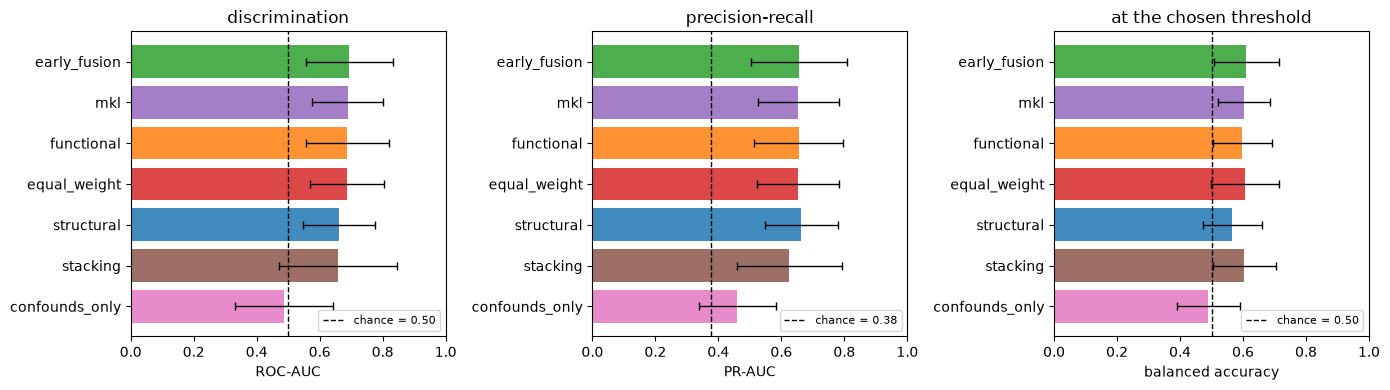

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("auc", "ROC-AUC", 0.5), ("pr_auc", "PR-AUC", folds["prevalence"].mean()),
           ("balanced_accuracy", "balanced accuracy", 0.5)]
for ax, (metric, label, chance) in zip(axes, metrics):
    means = summary.set_index("model").loc[order, f"{metric}_mean"]
    errors = summary.set_index("model").loc[order, f"{metric}_std"]
    ax.barh(order, means, xerr=errors, color=[COLORS[m] for m in order], alpha=0.85,
            error_kw={"elinewidth": 1, "capsize": 3})
    ax.axvline(chance, color="k", ls="--", lw=1, label=f"chance = {chance:.2f}")
    ax.set(xlabel=label, xlim=(0, 1))
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_title("discrimination")
axes[1].set_title("precision-recall")
axes[2].set_title("at the chosen threshold")
plt.tight_layout()
save(fig, "fig01_performance_by_model.png")
plt.show()

## Figure 2 — Spread across outer folds
Each box is 50 folds (10 repeats × 5 folds). Wide boxes mean the estimate depends heavily on which participants land in the test fold, which is what a sample of 82 buys you.

saved fig02_fold_spread.png


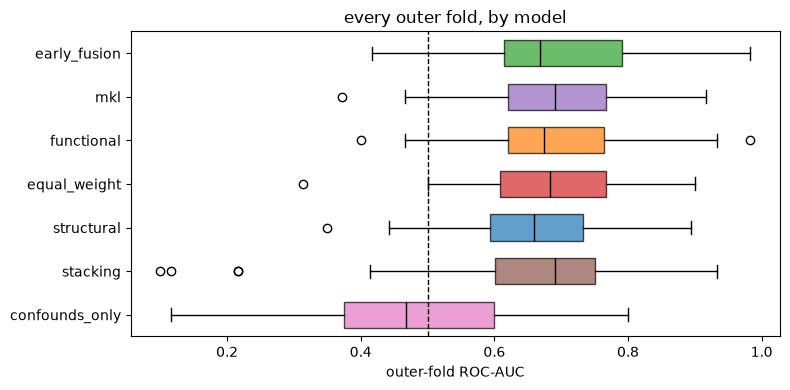

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [folds.loc[folds["model"] == m, "auc"] for m in order]
bp = ax.boxplot(data, orientation="horizontal", patch_artist=True, widths=0.6)
for patch, model in zip(bp["boxes"], order):
    patch.set_facecolor(COLORS[model])
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color("black")
ax.set_yticks(range(1, len(order) + 1), order)
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set(xlabel="outer-fold ROC-AUC", title="every outer fold, by model")
plt.tight_layout()
save(fig, "fig02_fold_spread.png")
plt.show()

## Figure 3 — All five metrics at once
Sensitivity and specificity are computed at the threshold chosen inside the inner loop. A model can trade one for the other; balanced accuracy averages them.

saved fig03_metric_grid.png


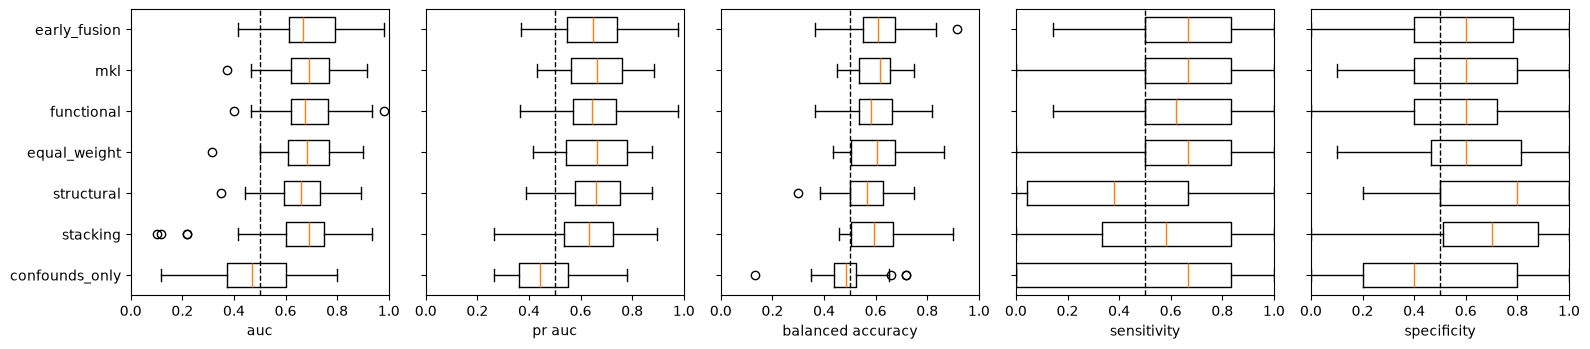

In [5]:
metric_names = ["auc", "pr_auc", "balanced_accuracy", "sensitivity", "specificity"]
fig, axes = plt.subplots(1, len(metric_names), figsize=(16, 3.6), sharey=True)
for ax, metric in zip(axes, metric_names):
    ax.boxplot([folds.loc[folds["model"] == m, metric] for m in order],
               orientation="horizontal", widths=0.6)
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set(xlabel=metric.replace("_", " "), xlim=(0, 1))
axes[0].set_yticks(range(1, len(order) + 1), order)
plt.tight_layout()
save(fig, "fig03_metric_grid.png")
plt.show()

## Figure 4 — Paired differences against MKL (forest plot)
Each row is a paired comparison on identical folds, with the Nadeau–Bengio corrected interval. The shaded band marks ±δ, the smallest difference declared meaningful in advance. Every interval covers zero *and* extends well past δ, which is the visual form of "inconclusive".

saved fig04_forest_paired_differences.png


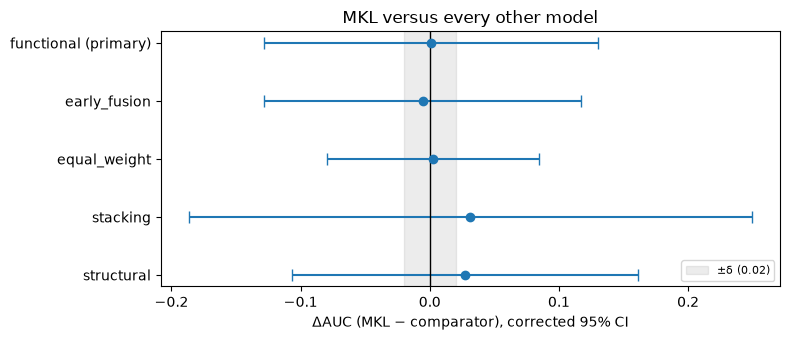

In [6]:
rows = [{"comparator": "functional (primary)", "mean_delta_auc": primary["mean_delta_auc"],
         "ci_low": primary["ci_low"], "ci_high": primary["ci_high"]}]
rows += comparisons[["comparator", "mean_delta_auc", "ci_low", "ci_high"]].to_dict("records")
forest = pd.DataFrame(rows)[::-1]
delta = primary["delta"]

fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(forest))
ax.axvspan(-delta, delta, color="grey", alpha=0.15, label=f"±δ ({delta})")
ax.errorbar(forest["mean_delta_auc"], y,
            xerr=[forest["mean_delta_auc"] - forest["ci_low"], forest["ci_high"] - forest["mean_delta_auc"]],
            fmt="o", color="tab:blue", capsize=4)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(y, forest["comparator"])
ax.set(xlabel="ΔAUC (MKL − comparator), corrected 95% CI", title="MKL versus every other model")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
save(fig, "fig04_forest_paired_differences.png")
plt.show()

## Figure 5 — The primary permutation null
The structural block was shuffled across participants 1,000 times, keeping labels and connectivity intact, and the whole nested pipeline re-run each time. The null sits slightly **below** zero: when the structural block is noise, MKL does a little worse than the functional model, because estimating β costs something. The observed difference (red) sits above that, but not far enough.

saved fig05_primary_null.png


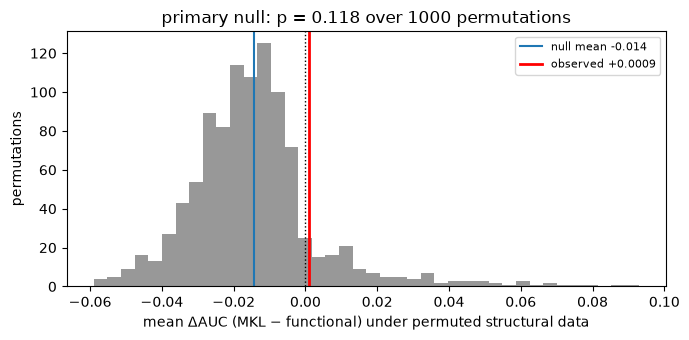

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(block_null["statistic"], bins=40, color="tab:grey", alpha=0.8)
ax.axvline(0, color="k", lw=1, ls=":")
ax.axvline(block_null["statistic"].mean(), color="tab:blue", lw=1.5, label=f"null mean {block_null['statistic'].mean():+.3f}")
ax.axvline(primary["mean_delta_auc"], color="red", lw=2, label=f"observed {primary['mean_delta_auc']:+.4f}")
ax.set(xlabel="mean ΔAUC (MKL − functional) under permuted structural data", ylabel="permutations",
       title=f"primary null: p = {primary['p_block_permutation']:.3f} over {len(block_null)} permutations")
ax.legend(fontsize=8)
plt.tight_layout()
save(fig, "fig05_primary_null.png")
plt.show()

## Figure 6 — Does each model beat chance?
Diagnosis labels permuted 1,000 times, pipeline re-run each time. Every imaging model's observed AUC (red) sits in the right tail of its null. The confound-only model sits in the middle of its null, which is the point: age, sex and motion alone do not separate these groups.

saved fig06_beats_chance_nulls.png


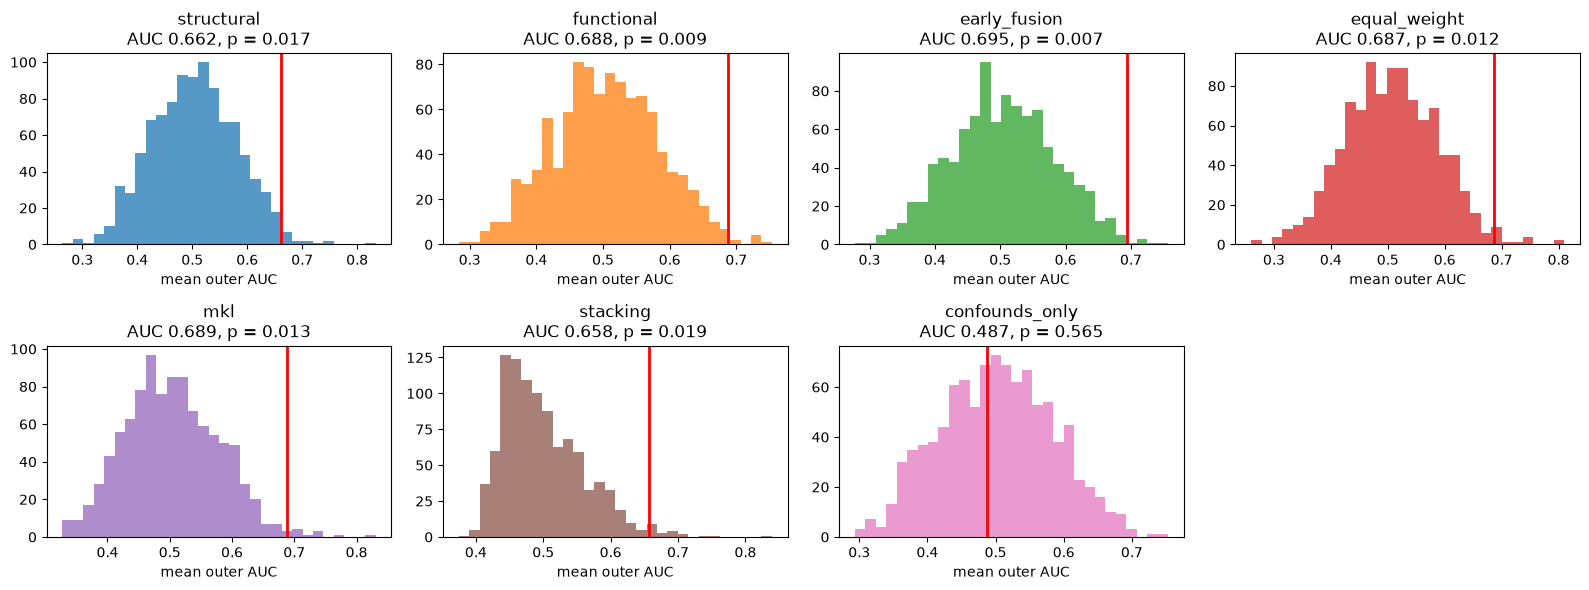

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
observed = folds.groupby("model")["auc"].mean()
for ax, model in zip(axes.ravel(), MODELS):
    ax.hist(label_null[model], bins=30, color=COLORS[model], alpha=0.75)
    ax.axvline(observed[model], color="red", lw=2)
    p = beats.set_index("model").loc[model, "p_permutation"]
    ax.set(title=f"{model}\nAUC {observed[model]:.3f}, p = {p:.3f}", xlabel="mean outer AUC")
axes.ravel()[-1].axis("off")
plt.tight_layout()
save(fig, "fig06_beats_chance_nulls.png")
plt.show()

## Figure 7 — What the inner loop chose
Left: the structural weight β that MKL selected in each fold, against early fusion's implicit weight (fixed by feature counts) and the equal-weight line. Middle: the regularization strength C, which indicates how hard each model had to be constrained. Right: the decision thresholds, picked from inner out-of-fold scores.

saved fig07_selected_hyperparameters.png


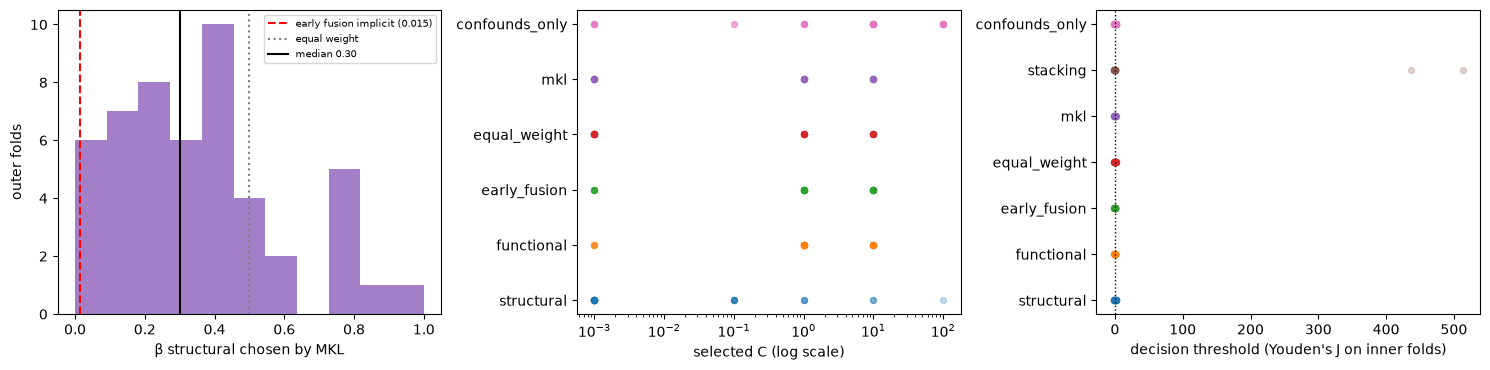

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
beta = selections[selections["model"] == "mkl"]["beta_structural"]
axes[0].hist(beta, bins=11, range=(0, 1), color=COLORS["mkl"], alpha=0.85)
axes[0].axvline(0.015, color="red", ls="--", label="early fusion implicit (0.015)")
axes[0].axvline(0.5, color="grey", ls=":", label="equal weight")
axes[0].axvline(beta.median(), color="k", lw=1.5, label=f"median {beta.median():.2f}")
axes[0].set(xlabel="β structural chosen by MKL", ylabel="outer folds")
axes[0].legend(fontsize=7)

for model in MODELS:
    values = selections.loc[selections["model"] == model, "C"].dropna()
    if len(values):
        axes[1].scatter(values, [model] * len(values), alpha=0.25, s=18, color=COLORS[model])
axes[1].set(xscale="log", xlabel="selected C (log scale)")

for model in MODELS:
    values = selections.loc[selections["model"] == model, "threshold"].dropna()
    if len(values):
        axes[2].scatter(values, [model] * len(values), alpha=0.25, s=18, color=COLORS[model])
axes[2].axvline(0, color="k", ls=":", lw=1)
axes[2].set(xlabel="decision threshold (Youden's J on inner folds)")
plt.tight_layout()
save(fig, "fig07_selected_hyperparameters.png")
plt.show()

## Figure 8 — ROC and precision-recall curves
Curves are computed **within each outer fold and averaged**, because decision scores from different fold models are on different scales. The shaded band is ±1 SD across folds.

saved fig08_roc_pr_curves.png


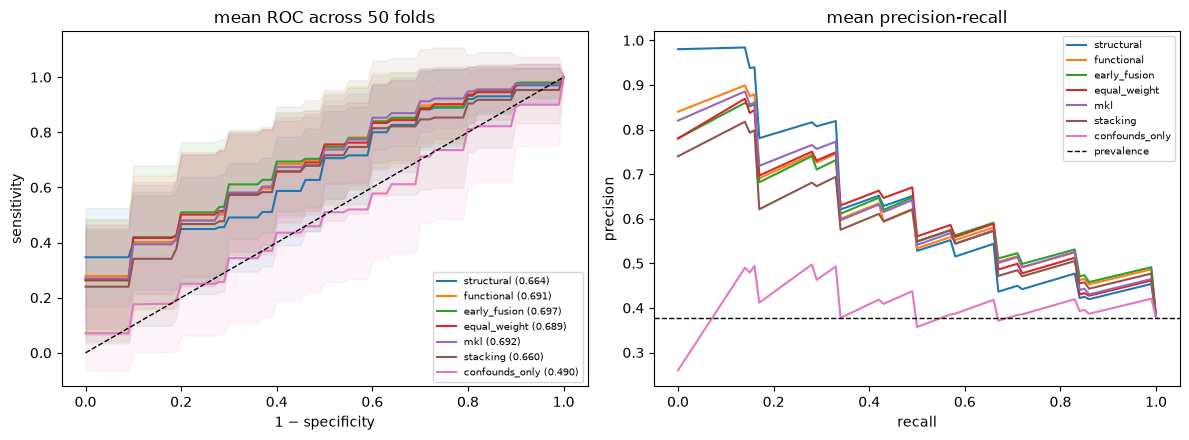

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as auc_score

grid = np.linspace(0, 1, 101)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model in MODELS:
    tprs, precisions = [], []
    for (_, _), group in predictions[predictions["model"] == model].groupby(["repeat", "fold"]):
        fpr, tpr, _ = roc_curve(group["y_true"], group["score"])
        tprs.append(np.interp(grid, fpr, tpr))
        precision, recall, _ = precision_recall_curve(group["y_true"], group["score"])
        precisions.append(np.interp(grid, recall[::-1], precision[::-1]))
    tprs, precisions = np.array(tprs), np.array(precisions)
    axes[0].plot(grid, tprs.mean(axis=0), color=COLORS[model], label=f"{model} ({auc_score(grid, tprs.mean(axis=0)):.3f})")
    axes[0].fill_between(grid, tprs.mean(0) - tprs.std(0), tprs.mean(0) + tprs.std(0), color=COLORS[model], alpha=0.08)
    axes[1].plot(grid, precisions.mean(axis=0), color=COLORS[model], label=model)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="1 − specificity", ylabel="sensitivity", title="mean ROC across 50 folds")
axes[0].legend(fontsize=7)
axes[1].axhline(predictions["y_true"].mean(), color="k", ls="--", lw=1, label="prevalence")
axes[1].set(xlabel="recall", ylabel="precision", title="mean precision-recall")
axes[1].legend(fontsize=7)
plt.tight_layout()
save(fig, "fig08_roc_pr_curves.png")
plt.show()

## Figure 9 — Where the decision scores fall
Patient and control score distributions for each model, pooled over folds for display. Overlap is the visual form of AUC ≈ 0.69: the distributions separate, but they sit mostly on top of each other.

saved fig09_score_distributions.png


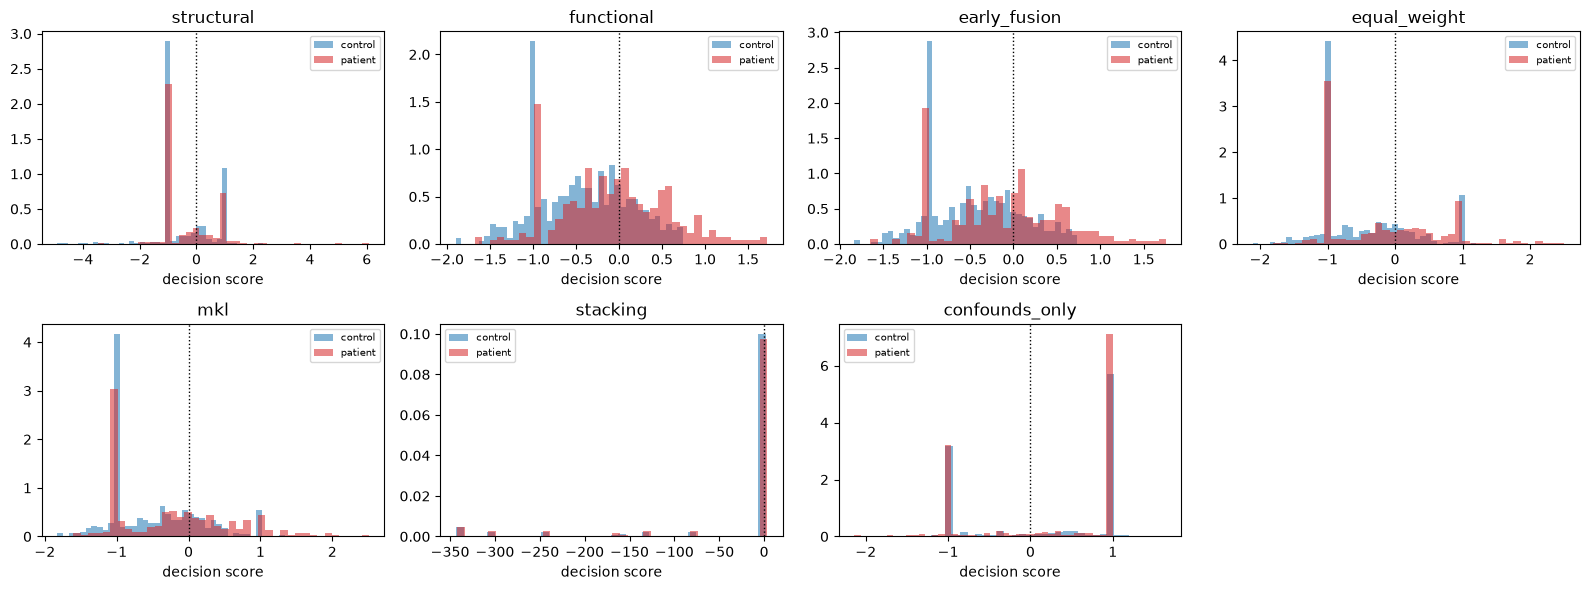

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=False)
for ax, model in zip(axes.ravel(), MODELS):
    subset = predictions[predictions["model"] == model]
    for label, name, colour in [(0, "control", "tab:blue"), (1, "patient", "tab:red")]:
        ax.hist(subset.loc[subset["y_true"] == label, "score"], bins=40, alpha=0.55,
                density=True, color=colour, label=name)
    ax.axvline(0, color="k", lw=1, ls=":")
    ax.set(title=model, xlabel="decision score")
    ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
plt.tight_layout()
save(fig, "fig09_score_distributions.png")
plt.show()

## Figure 10 — Prediction stability, participant by participant
Each participant was tested once per repeat, so each has 10 out-of-sample scores. Left: mean score against its spread — points far right or left are confidently classified, points high up are unstable. Right: how often each participant was called a patient. Values in the middle mean the model changed its mind depending on who else was in the training set.

saved fig10_prediction_stability.png


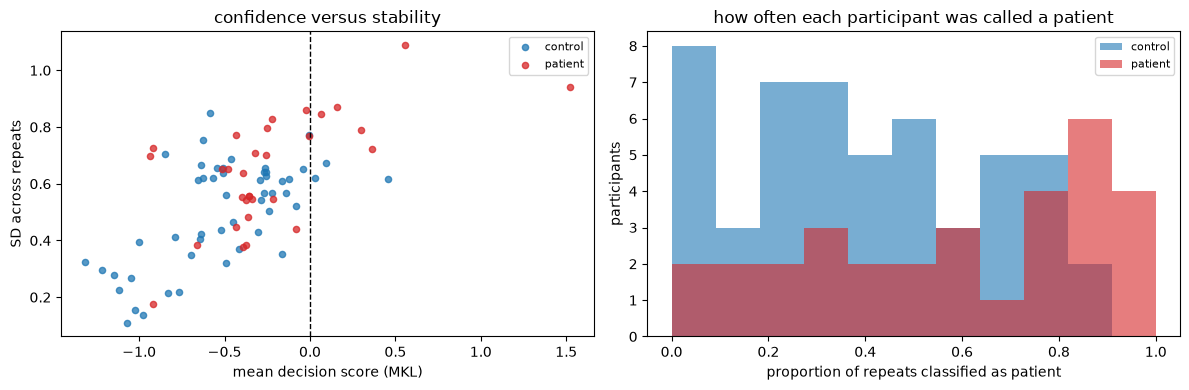

median score SD 0.59; 14/82 participants classified identically in all repeats


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name, colour in [(0, "control", "tab:blue"), (1, "patient", "tab:red")]:
    subset = stability[stability["y_true"] == label]
    axes[0].scatter(subset["mean_score"], subset["sd_score"], s=20, alpha=0.75, color=colour, label=name)
    axes[1].hist(subset["frac_predicted_patient"], bins=11, range=(0, 1), alpha=0.6, color=colour, label=name)
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].set(xlabel="mean decision score (MKL)", ylabel="SD across repeats", title="confidence versus stability")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="proportion of repeats classified as patient", ylabel="participants",
            title="how often each participant was called a patient")
axes[1].legend(fontsize=8)
plt.tight_layout()
save(fig, "fig10_prediction_stability.png")
plt.show()
print(f"median score SD {stability['sd_score'].median():.2f}; "
      f"{int(stability['frac_predicted_patient'].isin([0, 1]).sum())}/{len(stability)} participants "
      f"classified identically in all repeats")

## Figures 11 and 12 — What the model weighted
Weight vectors recovered from all 50 outer-fold fits. **These describe the fitted model, not the brain**: correlated features trade weight between folds, and a linear model's weights partly serve to cancel noise. Sign consistency (how often a feature keeps the sign of its mean weight) is the honest stability measure.

saved fig11_structural_weights.png


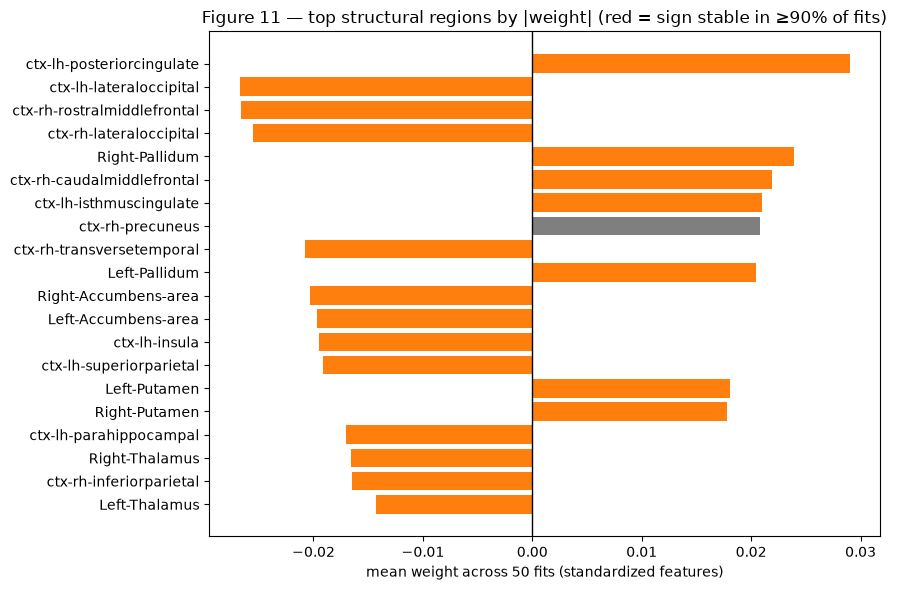

mean pairwise cosine similarity of structural weight vectors: 0.57


In [13]:
use_notebook("07_stability_and_confounds.ipynb")   # load_weights, weight_matrix, sign_consistency, network_aggregate

weights = load_weights(RESULTS / "predictions" / "primal_weights_multimodal.npz")
features_dir = ROOT / "data" / "derivatives" / "features"
structural_names = pd.read_csv(features_dir / "structural_features_fastsurfer.csv", nrows=0).columns[1:]
W = weight_matrix(weights, "mkl", "structural")
mean_w = W.mean(axis=0)
consistency = sign_consistency(W)
top = np.argsort(np.abs(mean_w))[::-1][:20][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
colours = ["tab:red" if c >= 0.9 else "tab:orange" if c >= 0.75 else "tab:grey" for c in consistency[top]]
ax.barh([structural_names[i].replace("vol_", "") for i in top], mean_w[top], color=colours)
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="mean weight across 50 fits (standardized features)",
       title="Figure 11 — top structural regions by |weight| (red = sign stable in ≥90% of fits)")
plt.tight_layout()
save(fig, "fig11_structural_weights.png")
plt.show()
print(f"mean pairwise cosine similarity of structural weight vectors: {mean_pairwise_similarity(W):.2f}")

saved fig12_functional_network_weights.png


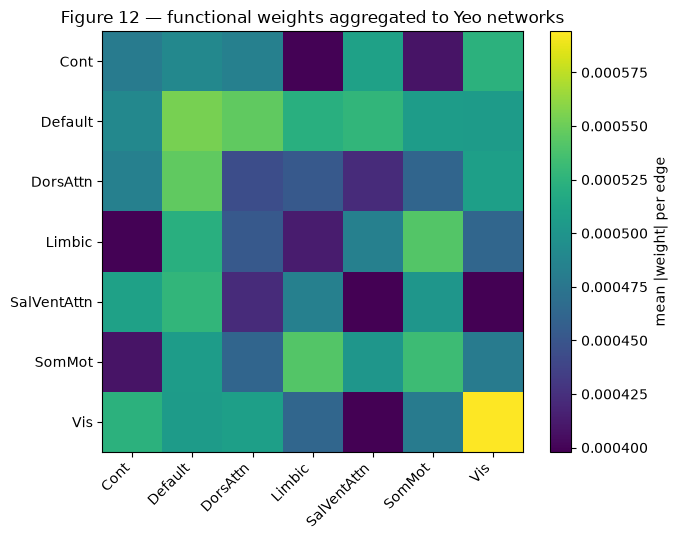

mean pairwise cosine similarity of functional weight vectors: 0.67


In [14]:
edges = pd.read_csv(features_dir / "functional_edges.csv")
Wf = weight_matrix(weights, "mkl", "functional")
networks = network_aggregate(Wf.mean(axis=0), edges)
pivot = networks.pivot(index="network_a", columns="network_b", values="mean_abs_weight")
pivot = pivot.combine_first(pivot.T)

fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(pivot.to_numpy(), cmap="viridis")
ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)), pivot.index)
fig.colorbar(image, ax=ax, label="mean |weight| per edge")
ax.set_title("Figure 12 — functional weights aggregated to Yeo networks")
plt.tight_layout()
save(fig, "fig12_functional_network_weights.png")
plt.show()
print(f"mean pairwise cosine similarity of functional weight vectors: {mean_pairwise_similarity(Wf):.2f}")

## Figure 13 — The functional-only run versus the multimodal run
The earlier exploratory run used the same 82 participants but only connectivity. Adding the structural block changed essentially nothing, which is the same message as the primary test, seen from a different angle.

saved

 fig13_functional_vs_multimodal.png


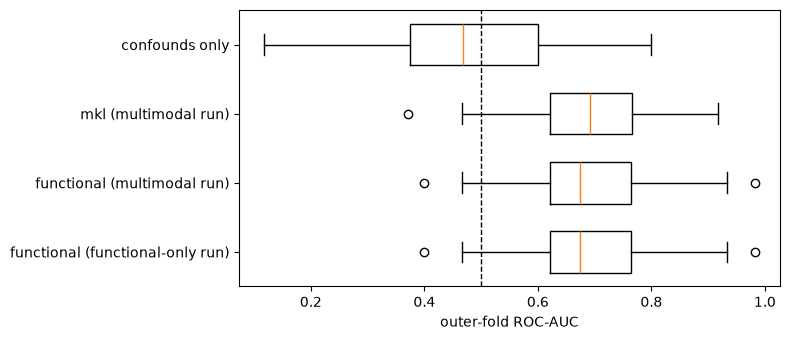

In [15]:
functional_only = pd.read_csv(RESULTS / "metrics" / "fold_metrics_niak_functional.csv")
fig, ax = plt.subplots(figsize=(8, 3.5))
pairs = [("functional (functional-only run)", functional_only.loc[functional_only["model"] == "functional", "auc"]),
         ("functional (multimodal run)", folds.loc[folds["model"] == "functional", "auc"]),
         ("mkl (multimodal run)", folds.loc[folds["model"] == "mkl", "auc"]),
         ("confounds only", folds.loc[folds["model"] == "confounds_only", "auc"])]
ax.boxplot([values for _, values in pairs], orientation="horizontal", widths=0.6)
ax.set_yticks(range(1, len(pairs) + 1), [name for name, _ in pairs])
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set(xlabel="outer-fold ROC-AUC")
plt.tight_layout()
save(fig, "fig13_functional_vs_multimodal.png")
plt.show()

In [16]:
print("figures written to results/figures:")
for path in sorted(FIGURES.glob("fig*.png")):
    print(f"  {path.name:45s} {path.stat().st_size // 1024} KB")

figures written to results/figures:
  fig01_performance_by_model.png                60 KB
  fig02_fold_spread.png                         35 KB
  fig03_metric_grid.png                         53 KB
  fig04_forest_paired_differences.png           31 KB
  fig05_primary_null.png                        36 KB
  fig06_beats_chance_nulls.png                  112 KB
  fig07_selected_hyperparameters.png            79 KB
  fig08_roc_pr_curves.png                       190 KB
  fig09_score_distributions.png                 104 KB
  fig10_prediction_stability.png                68 KB
  fig11_structural_weights.png                  85 KB
  fig12_functional_network_weights.png          52 KB
  fig13_functional_vs_multimodal.png            27 KB
